In [1]:
import os
import boto3
import json
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import shape
import matplotlib.pyplot as plt
from botocore.exceptions import ClientError
import mlflow
import mlflow.pytorch
import torch
from snowML.datapipe.utils import data_utils as du
from snowML.datapipe.utils import get_geos as gg
from sklearn.metrics import mean_squared_error

/home/sagemaker-user/.conda/envs/myenv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [10]:
s3_client = boto3.client('s3', region_name='us-west-2')

BUCKET_NAME = 'snowml-shape'
GOLD_LAYER_BUCKET = 'snowml-gold'
MODEL_READY_BUCKET = 'snowml-model-ready-stgnn'

# Load Geojson Data of HUC12s in the PNW region from `snowml-shape` bucket

In [4]:
def get_geo_jsons(huc_ids, huc_level, bucket_nm="snowml-shape"):
    gdf = []
    for huc_id in huc_ids:
        temp = None
        f_out = f"Huc{huc_level}_in_{huc_id}.geojson"
        if du.isin_s3(bucket_nm, f_out):
            print(f"Getting geos from s3 bucket for {huc_id}")
            temp = du.s3_to_gdf(bucket_nm, f_out)
        else:
            try:
                print(f"Getting geos from google earth for {huc_id}")
                temp = gg.get_geos(huc_id, huc_level, s3_save=True, bucket_nm=bucket_nm)
            except Exception as e:
                # log the error and continue; store None for this huc_id
                print(f"Error getting geos for {huc_id}: {e}")
        if temp is not None:
            temp['huc8'] = huc_id  # Add huc8 df column for all rows in this GeoDataFrame
            gdf.append(temp)
            print(f"Found {len(temp)} HUC {huc_level}s in {huc_id}")
    return gpd.GeoDataFrame(pd.concat(gdf, ignore_index=True))

In [5]:
huc8_ids = [17020009, 17020011, 17110005, 17110006,  17110009, 17010304, 17010302, 17060207, 17060208, 17030001, 17030002, 17110008, 17030003, 17020010, 17110007] # list of huc8s
# huc8_ids = [17020009, 17020011, 17110005, 17110006,  17110009]
gdf = get_geo_jsons(huc8_ids, "12")
print(len(gdf))

Getting geos from s3 bucket for 17020009
Found 29 HUC 12s in 17020009
Getting geos from s3 bucket for 17020011
Found 43 HUC 12s in 17020011
Getting geos from s3 bucket for 17110005
Found 57 HUC 12s in 17110005
Getting geos from s3 bucket for 17110006
Found 21 HUC 12s in 17110006
Getting geos from s3 bucket for 17110009
Found 21 HUC 12s in 17110009
Getting geos from s3 bucket for 17010304
Found 52 HUC 12s in 17010304
Getting geos from s3 bucket for 17010302
Found 8 HUC 12s in 17010302
Getting geos from s3 bucket for 17060207
Found 51 HUC 12s in 17060207
Getting geos from s3 bucket for 17060208
Found 44 HUC 12s in 17060208
Getting geos from s3 bucket for 17030001
Found 52 HUC 12s in 17030001
Getting geos from s3 bucket for 17030002
Found 29 HUC 12s in 17030002
Getting geos from s3 bucket for 17110008
Found 20 HUC 12s in 17110008
Getting geos from s3 bucket for 17030003
Found 72 HUC 12s in 17030003
Getting geos from s3 bucket for 17020010
Found 41 HUC 12s in 17020010
Getting geos from s3 

In [6]:
huc12_ids = gdf['huc_id']

In [7]:
EXCLUDED_HUCS_CA = ["1711000501", "1711000502", "1711000503", "171100050101", "171100050102", \
                "171100050201", "171100050202", "171100050203", "171100050301", \
                "171100050302", "171100050303", "171100050304", "171100050305", \
                "171100050306", "171100050401"] 

In [8]:
huc12_ids = [huc for huc in huc12_ids if huc not in EXCLUDED_HUCS_CA]
len(huc12_ids)

539

In [9]:
gdf = gdf[~gdf['huc_id'].isin(EXCLUDED_HUCS_CA)]
len(gdf)

539

# Load timeseries and static data from `snowml-model-ready` bucket

In [11]:
model_ready_files = [f'model_ready_huc{huc_id}.csv' for huc_id in huc12_ids]
missing_files = [f for f in model_ready_files if not du.isin_s3(MODEL_READY_BUCKET, f)]
print(f"Number of missing files: {len(missing_files)}")
print("Missing files:", missing_files)

Number of missing files: 0
Missing files: []


In [12]:
def get_model_ready_data(huc_ids, bucket_nm=MODEL_READY_BUCKET):
    huc_dfs = []
    for huc_id in huc_ids:
        f_out = f"model_ready_huc{huc_id}.csv"
        df = du.s3_to_df(f_out, bucket_nm)
        df['huc_id'] = huc_id
        huc_dfs.append(df)
    return pd.concat(huc_dfs, ignore_index=True)

huc_dfs = get_model_ready_data(huc12_ids, MODEL_READY_BUCKET)
print(huc_dfs.head())

          day  mean_pr  mean_tair  mean_vs  mean_srad  mean_hum  mean_swe  \
0  1983-10-01     0.00     2.8250    3.100    114.875  0.474750  0.000333   
1  1983-10-02     0.00     3.0500    4.250    159.050  0.633750  0.000000   
2  1983-10-03     1.55     3.8750    5.450    122.525  0.746500  0.000000   
3  1983-10-04     0.50     2.3125    4.350    179.775  0.728875  0.000000   
4  1983-10-05     0.00     2.2125    3.175    148.275  0.643000  0.000000   

   Mean Elevation Predominant Snow  Mean Forest Cover  ...        huc_id  \
0     1758.266724         Maritime          38.389219  ...  170200090101   
1     1758.266724         Maritime          38.389219  ...  170200090101   
2     1758.266724         Maritime          38.389219  ...  170200090101   
3     1758.266724         Maritime          38.389219  ...  170200090101   
4     1758.266724         Maritime          38.389219  ...  170200090101   

   Unnamed: 0  Tundra  Boreal Forest  Maritime  Ephemeral Prairie  \
0         N

In [13]:
# print(len(huc_dfs))
huc_dfs.columns

Index(['day', 'mean_pr', 'mean_tair', 'mean_vs', 'mean_srad', 'mean_hum',
       'mean_swe', 'Mean Elevation', 'Predominant Snow', 'Mean Forest Cover',
       'mean_swe_lag_7', 'mean_swe_lag_30', 'mean_swe_lag_60', 'snow_cover',
       'era5_swe', 'slope', 'huc_id', 'Unnamed: 0', 'Tundra', 'Boreal Forest',
       'Maritime', 'Ephemeral', 'Prairie', 'Montane Forest', 'Ice', 'Ocean'],
      dtype='object')

In [12]:
na_rows = huc_dfs[huc_dfs['mean_swe_lag_30'].isna()].copy()
print(na_rows.groupby('huc_id').size())
na_rows['day'].min(), na_rows['day'].max(), len(na_rows)

huc_id
170103020101    30
170103020102    30
170103020103    30
170103020201    30
170103020202    30
                ..
171100090601    30
171100090602    30
171100090603    30
171100090701    30
171100090702    30
Length: 539, dtype: int64


('1983-10-01', '1983-10-30', 16170)

In [13]:
huc_dfs = huc_dfs.dropna(subset=['mean_swe_lag_30']).copy()
len(huc_dfs)

7661346

In [18]:
snow_cols = ["Tundra", "Boreal Forest", "Maritime", "Ephemeral", "Prairie", "Montane Forest", "Ice", "Ocean"]
mask = huc_dfs[snow_cols].isna().any(axis=1)

# get unique huc_ids
hucs_with_na = huc_dfs.loc[mask, 'huc_id'].unique()

print(len(hucs_with_na))
# mask = huc_dfs["Predominant Snow"].isna()

# Pick the column name with the highest value among snow_cols for each NA row
# picked = huc_dfs.loc[mask, snow_cols].idxmax(axis=1)

# # # Optional: handle rows where all snow_cols are NaN (idxmax would error / return NaN depending on pandas version)
# # picked = picked.fillna("Unknown")

# # Replace Predominant Snow only where it was NA
# huc_dfs.loc[mask, "Predominant Snow"] = picked

535


In [ ]:
mask

## Create Time Series input tensor

In [18]:
def get_time_series_data(huc_dfs, feature_names = ['mean_pr', 'mean_tair', 'mean_swe_lag_30']):

    huc_groups = huc_dfs.groupby('huc_id')['day'].apply(lambda x: set(x.astype(str)))
    common_timestamps = set.intersection(*huc_groups)
    master_index = sorted(common_timestamps)

    all_data = []
    target_data = []
    huc_ids = list(huc_dfs['huc_id'].unique())
    for huc in huc_ids:
        df = huc_dfs[huc_dfs['huc_id'] == huc].copy()
        df['day'] = df['day'].astype(str)
        df = df.set_index('day').reindex(master_index)
        # Features
        features = df[feature_names].values.T.astype(float)  # shape: [num_features, num_timesteps]
        all_data.append(features)
        # Target
        target = df['mean_swe'].values.astype(float)  # shape: [num_timesteps]
        target_data.append(target)

    dynamic_features = torch.tensor(np.array(all_data), dtype=torch.float32)  # [num_hucs, num_features, num_timesteps]
    target_tensor = torch.tensor(np.array(target_data), dtype=torch.float32)  # [num_hucs, num_timesteps]
    return dynamic_features, target_tensor

# Generate adjacency matrix with static variables


In [19]:
gdf.columns

Index(['huc_id', 'geometry', 'huc8'], dtype='object')

In [20]:
def generate_huc12_adjacency_matrix(gdf, use_geographic_adjacency=True):
    """
    Generate adjacency matrix for HUC12 watersheds based on boundary sharing.

    Parameters:
    - gdf: GeoDataFrame with HUC12 watersheds
    - use_geographic_adjacency: If True, add edges for watersheds that share boundaries

    Returns:
    - adj_matrix: Adjacency matrix (numpy array)
    - node_ids: List of HUC12 IDs corresponding to matrix rows/cols
    - coordinates: Centroid coordinates for each node
    """
    num_nodes = len(gdf)
    adj_matrix = np.zeros((num_nodes, num_nodes))

    # Get HUC12 IDs
    node_ids = gdf['huc_id'].tolist()

    # Project to UTM for all geometric operations
    gdf_projected = gdf.to_crs(epsg=32610)

    # Extract centroids for visualization
    centroids = gdf_projected.geometry.centroid
    coordinates = np.array([[c.x, c.y] for c in centroids])

    # Connect watersheds that share a boundary (geographic adjacency)
    if use_geographic_adjacency:
        print("Building adjacency based on shared boundaries...")
        for i in range(num_nodes):
            if i % 10 == 0:
                print(f"  Processing node {i}/{num_nodes}...")
            geom_i = gdf_projected.iloc[i].geometry
            for j in range(i+1, num_nodes):
                geom_j = gdf_projected.iloc[j].geometry
                if geom_i.touches(geom_j):
                    adj_matrix[i, j] = 1.0  # Edge weight for direct neighbors
                    adj_matrix[j, i] = 1.0

    print(f"Adjacency matrix created: {num_nodes}x{num_nodes}")
    print(f"Number of edges: {int(np.sum(adj_matrix > 0) / 2)}")

    return adj_matrix, node_ids, coordinates

def normalize(arr):
    """
    Min-max normalize a numpy array or PyTorch tensor to [0, 1].
    Handles NaNs by ignoring them in min/max calculation.
    """
    arr = np.array(arr)
    arr_min = np.nanmin(arr)
    arr_max = np.nanmax(arr)
    if arr_max - arr_min == 0:
        return np.zeros_like(arr)
    return (arr - arr_min) / (arr_max - arr_min)

def create_static_features(gdf, coordinates, huc_dfs):
    """
    Create static node features for ST-GNN:
    - Normalized x, y coordinates
    - Watershed area (normalized)
    - One-hot encoded Predominant Snow columns
    - Mean Forest Cover (normalized)
    - Mean Elevation (normalized)
    Returns:
    - static_features: PyTorch tensor of shape (num_nodes, num_features)
    """
    num_nodes = len(gdf)
    gdf_projected = gdf.to_crs(epsg=32610)
    areas = gdf_projected.geometry.area.values

    x_coords = coordinates[:, 0]
    y_coords = coordinates[:, 1]

    # Match static variables by HUC12 ID
    huc_ids = gdf['huc_id'].tolist()
    static_df = huc_dfs.drop_duplicates('huc_id').set_index('huc_id').reindex(huc_ids)

    # One-hot encode 'Predominant Snow'
    snow_onehot = pd.get_dummies(static_df['Predominant Snow'].fillna('Unknown'), prefix='snow')
    snow_onehot = snow_onehot.values  # shape: (num_nodes, num_snow_types)
    snow_onehot_cols = snow_onehot.shape[1]

    # huc8_onehot_df = pd.get_dummies(
    #     gdf['huc8'].astype(str),
    #     prefix='huc8'
    # )
    # huc8_onehot = huc8_onehot_df.values

    # Extract and normalize other static features
    x_normalized = normalize(x_coords)
    y_normalized = normalize(y_coords)
    area_normalized = normalize(areas)
    elev_normalized = normalize(static_df['Mean Elevation'].values)

    # Combine all features
    # feature_list = [
    #     x_normalized[:, None],  # shape (num_nodes, 1)
    #     y_normalized[:, None],
    #     area_normalized[:, None],
    #     elev_normalized[:, None],
    #     snow_onehot,   # shape (num_nodes, num_snow_types)
    #     huc8_onehot
    # ]
    feature_list = [
        x_normalized[:, None],  # shape (num_nodes, 1)
        y_normalized[:, None],
        area_normalized[:, None],
        elev_normalized[:, None],
        snow_onehot   # shape (num_nodes, num_snow_types)
    ]
    features = np.concatenate(feature_list, axis=1)

    # Feature names for reference
    feature_names = [
        'x_coord', 'y_coord', 'area', 'mean_elevation'
    ] + list(pd.get_dummies(static_df['Predominant Snow'].fillna('Unknown')).columns)

    # + list(huc8_onehot_df.columns)

    static_features = torch.tensor(features, dtype=torch.float32)

    print(f"Static features shape: {static_features.shape}")
    print(f"Features: {feature_names}")

    return static_features

In [21]:
huc_dfs.dtypes

day                   object
mean_pr              float64
mean_tair            float64
mean_vs              float64
mean_srad            float64
mean_hum             float64
mean_swe             float64
Mean Elevation       float64
Predominant Snow      object
Mean Forest Cover    float64
mean_swe_lag_7       float64
mean_swe_lag_30      float64
mean_swe_lag_60      float64
huc_id                object
Unnamed: 0           float64
Tundra               float64
Boreal Forest        float64
Maritime             float64
Ephemeral            float64
Prairie              float64
Montane Forest       float64
Ice                  float64
Ocean                float64
dtype: object

In [22]:
train_end = '2015-12-31'
test_start = '2016-01-01'

train_df = huc_dfs[huc_dfs['day'] <= train_end]
test_df = huc_dfs[huc_dfs['day'] >= test_start]

In [23]:
# Generate ST-GNN adjacency matrix and features
print("Creating ST-GNN Graph Structure...")
gdf_huc12 = gdf.copy()
# Generate adjacency matrix (boundary sharing only)
adj_matrix, node_ids, coordinates = generate_huc12_adjacency_matrix(gdf_huc12)

# Create static features
static_features = create_static_features(gdf_huc12, coordinates, huc_dfs)

Creating ST-GNN Graph Structure...
Building adjacency based on shared boundaries...
  Processing node 0/539...
  Processing node 10/539...
  Processing node 20/539...
  Processing node 30/539...
  Processing node 40/539...
  Processing node 50/539...
  Processing node 60/539...
  Processing node 70/539...
  Processing node 80/539...
  Processing node 90/539...
  Processing node 100/539...
  Processing node 110/539...
  Processing node 120/539...
  Processing node 130/539...
  Processing node 140/539...
  Processing node 150/539...
  Processing node 160/539...
  Processing node 170/539...
  Processing node 180/539...
  Processing node 190/539...
  Processing node 200/539...
  Processing node 210/539...
  Processing node 220/539...
  Processing node 230/539...
  Processing node 240/539...
  Processing node 250/539...
  Processing node 260/539...
  Processing node 270/539...
  Processing node 280/539...
  Processing node 290/539...
  Processing node 300/539...
  Processing node 310/539...

In [24]:
dynamic_features, target_tensor = get_time_series_data(huc_dfs)
print(dynamic_features.shape, target_tensor.shape)
unique_days = sorted(huc_dfs['day'].unique())
train_end_date = '2015-12-31'
test_start_date = '2016-01-01'

train_idx = sum(1 for d in unique_days if d <= train_end_date)
# text_idx = sum(1 for d in unique_days if d >= test_start_date)

# Create train data (val set held out for later)
train_dynamic = dynamic_features[:, :, :train_idx]
train_target = target_tensor[:, :train_idx]
print(train_dynamic.shape, train_target.shape)
# Calculate test fraction
# test_fraction = (text_idx) / (text_idx+train_idx)

print(f"Train: up to {train_end_date} ({train_idx} timesteps)")
# print(f"Test: ({text_idx} timesteps)")
# print(f"Test fraction: {test_fraction:.3f}")

torch.Size([539, 3, 14214]) torch.Size([539, 14214])
torch.Size([539, 3, 11750]) torch.Size([539, 11750])
Train: up to 2015-12-31 (11750 timesteps)


In [25]:
adj_matrix = torch.tensor(adj_matrix, dtype=torch.float32)  # Ensure it's a torch tensor
print(train_dynamic.shape)
print(train_target.shape)
print(adj_matrix.shape)
print(static_features.shape)

torch.Size([539, 3, 11750])
torch.Size([539, 11750])
torch.Size([539, 539])
torch.Size([539, 9])


In [26]:
import importlib
import train_model
importlib.reload(train_model)
from train_model import train_model
from train_model import test_model

In [27]:
import boto3
sm = boto3.client("sagemaker", region_name="us-west-2")

resp = sm.describe_mlflow_tracking_server(TrackingServerName="wi26-snowml-mlflow")
print(resp["MlflowVersion"])

3.0.0


2026/02/24 09:43:27 INFO mlflow.tracking.fluent: Experiment with name 'STGNN_SWE_in_m' does not exist. Creating a new experiment.


training model
Using device: cuda
Train samples: 9370, Val samples: 2320
Epoch 1/20
Train - Loss: 0.1384, MSE: 0.1385, KGE: 0.1834
Val   - MSE: 0.0124, KGE: 0.8189
Epoch 2/20
Train - Loss: 0.0128, MSE: 0.0128, KGE: 0.8901
Val   - MSE: 0.0063, KGE: 0.8308
Epoch 3/20
Train - Loss: 0.0079, MSE: 0.0079, KGE: 0.9307
Val   - MSE: 0.0048, KGE: 0.8134
Epoch 4/20
Train - Loss: 0.0057, MSE: 0.0057, KGE: 0.9486
Val   - MSE: 0.0036, KGE: 0.8187
Epoch 5/20
Train - Loss: 0.0045, MSE: 0.0045, KGE: 0.9586
Val   - MSE: 0.0031, KGE: 0.8108
Epoch 6/20
Train - Loss: 0.0037, MSE: 0.0037, KGE: 0.9652
Val   - MSE: 0.0022, KGE: 0.9436
Epoch 7/20
Train - Loss: 0.0034, MSE: 0.0034, KGE: 0.9689
Val   - MSE: 0.0021, KGE: 0.9013
Epoch 8/20
Train - Loss: 0.0030, MSE: 0.0030, KGE: 0.9724
Val   - MSE: 0.0019, KGE: 0.9220
Epoch 9/20
Train - Loss: 0.0028, MSE: 0.0028, KGE: 0.9743
Val   - MSE: 0.0021, KGE: 0.8622
Epoch 10/20
Train - Loss: 0.0025, MSE: 0.0025, KGE: 0.9764
Val   - MSE: 0.0018, KGE: 0.9218
Epoch 11/20
Trai

2026/02/24 10:15:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/24 10:15:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run without_huc8_encoding at: https://us-west-2.experiments.sagemaker.aws/#/experiments/5/runs/f028efb84e87406788457f6947440737
🧪 View experiment at: https://us-west-2.experiments.sagemaker.aws/#/experiments/5


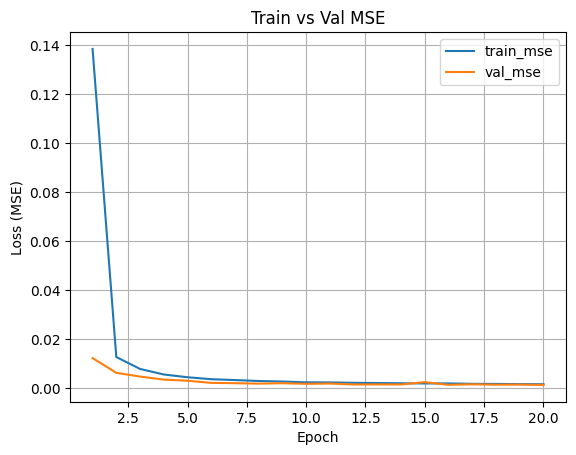

In [29]:
mlflow.end_run()
# mlflow.set_tracking_uri("st_gnn_data/mlruns")
mlflow.set_tracking_uri("arn:aws:sagemaker:us-west-2:677276086662:mlflow-tracking-server/wi26-snowml-mlflow")
# mlflow.set_experiment("STGNN_SWE_in_mm")
model = train_model(
    dynamic_features=train_dynamic,
    target_tensor=train_target,
    adj_matrix=adj_matrix,
    static_features=static_features,
    num_epochs=20,
    experiment_name="STGNN_SWE_in_m",
    run_name="without_huc8_encoding"
)

In [30]:
test_dynamic = dynamic_features[:, :, train_idx:]
test_target = target_tensor[:, train_idx:]
preds, targets = test_model(model=model,
                            dynamic_features=test_dynamic,
                            target_tensor=test_target,
                            adj_matrix=adj_matrix,
                            static_features=static_features)

Using device: cuda


/home/sagemaker-user/SnowML/src/snowML/STGNN/train_model.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  adj = torch.tensor(adj_matrix, dtype=torch.float32).to(device)


Predicts shape :(539, 2434)
Targets shape :(539, 2434)


In [31]:
os.makedirs("tmp", exist_ok=True)

path = "tmp/preds_targets.npz"

np.savez_compressed(
    path,
    predictions=preds,
    targets=targets
)

mlflow.log_artifact(path, artifact_path="model_outputs")

In [32]:
# from train_model import compute_metrics
# compute_metrics(targets, preds)
static_df = (
    huc_dfs.drop_duplicates('huc_id')
    .set_index('huc_id')
    .reindex(gdf['huc_id'])
)

static_df_filters = static_df[['Predominant Snow', 'Mean Elevation']]
static_df_filters

,Predominant Snow,Mean Elevation
huc_id,,
170200090101,Maritime,1758.266724
170200090102,Maritime,1675.947876
170200090103,Maritime,1568.105591
170200090104,Maritime,1523.352051
170200090105,Maritime,1541.539062
...,...,...
171100070107,Ephemeral,341.616608
171100070201,Ephemeral,379.928558
171100070202,Ephemeral,133.603516


In [33]:
from sklearn.metrics import mean_squared_error

def kling_gupta_efficiency(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    # NaN check
    if np.isnan(y_true).any() or np.isnan(y_pred).any():
        return np.nan, np.nan, np.nan, np.nan

    # Zero variance check
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan, np.nan, np.nan, np.nan

    r = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / (np.std(y_true) + eps)

    mean_true = np.mean(y_true)
    if np.isclose(mean_true, 0.0):
        beta = np.nan
    else:
        beta = np.mean(y_pred) / (mean_true + eps)

    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    return kge, r, alpha, beta
    
eps = 1e-8
num_hucs = preds.shape[0]

rows = []
for i in range(num_hucs):
    huc12 = huc12_ids[i]

    y_true = targets[i]
    y_pred = preds[i]

    # MSE
    mse = mean_squared_error(y_true, y_pred)
    kge, r, alpha, beta = kling_gupta_efficiency(y_true, y_pred, eps=eps)

    # 🔹 Static lookups
    snow_type = static_df_filters.loc[huc12, 'Predominant Snow']
    elevation = static_df_filters.loc[huc12, 'Mean Elevation']

    rows.append({
        "huc12": huc12,
        "huc8": huc12[:8],
        "snow_type": snow_type,
        "mean_elevation": elevation,
        "mse": mse,
        "kge": kge,
        "mean_true_swe": np.mean(y_true),
        "mean_pred_swe": np.mean(y_pred),
    })

huc_12s_wise = pd.DataFrame(rows)
huc_12s_wise.to_csv("huc12_wise_metrics_without_huc8_in_m.csv", index=False)
huc_12s_wise

NameError: name 'huc_12s_wiseaass' is not defined

In [34]:
huc_12s_wise

,huc12,huc8,snow_type,mean_elevation,mse,kge,mean_true_swe,mean_pred_swe
0,170200090101,17020009,Maritime,1758.266724,0.003038,0.966376,0.425640,0.432768
1,170200090102,17020009,Maritime,1675.947876,0.006487,0.894341,0.426703,0.452078
2,170200090103,17020009,Maritime,1568.105591,0.002963,0.933906,0.349154,0.363928
3,170200090104,17020009,Maritime,1523.352051,0.005639,0.937283,0.406574,0.427586
4,170200090105,17020009,Maritime,1541.539062,0.006332,0.969871,0.524265,0.535727
...,...,...,...,...,...,...,...,...
534,171100070107,17110007,Ephemeral,341.616608,0.000717,0.354448,0.023339,0.013650
535,171100070201,17110007,Ephemeral,379.928558,0.002165,0.394983,0.051801,0.028905
536,171100070202,17110007,Ephemeral,133.603516,0.000029,-0.239606,0.001176,0.001579
537,171100070203,17110007,Ephemeral,19.384562,0.000010,-1.635900,0.000382,0.001309


In [63]:
huc12_ids = gdf["huc_id"].values
huc8_ids  = gdf["huc8"].values
eps = 1e-8
rows = []

num_huc12, num_t = preds.shape

for i in range(num_huc12):
    for t in range(num_t):
        rows.append({
            "huc12": huc12_ids[i],
            "huc8": huc8_ids[i],
            "y_true": targets[i, t],
            "y_pred": preds[i, t],
        })

eval_df = pd.DataFrame(rows)

In [65]:
huc8_rows = []

for huc8, df in eval_df.groupby("huc8"):
    y_true = df["y_true"].values
    y_pred = df["y_pred"].values

    # MSE
    mse = mean_squared_error(y_true, y_pred)

    # KGE
    r = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / (np.std(y_true) + eps)
    beta = np.mean(y_pred) / (np.mean(y_true) + eps)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    huc8_rows.append({
        "huc8": huc8,
        "mse": mse,
        "kge": kge,
        "n_samples": len(df),
        "mean_true_swe": np.mean(y_true),
        "mean_pred_swe": np.mean(y_pred),
    })

huc8_metrics_df = pd.DataFrame(huc8_rows)
huc8_metrics_df

,huc8,mse,kge,n_samples,mean_true_swe,mean_pred_swe
0,17010302,0.001615,0.879824,19472,0.097724,0.108671
1,17010304,0.000782,0.952804,126568,0.092253,0.096214
2,17020009,0.003273,0.975231,70586,0.279603,0.284781
3,17020010,0.000743,0.949597,99794,0.060761,0.063504
4,17020011,0.003916,0.971756,104662,0.242006,0.243061
5,17030001,0.000994,0.961033,126568,0.097478,0.101097
6,17030002,0.001259,0.975505,70586,0.173382,0.173226
7,17030003,0.000173,0.810322,175248,0.012381,0.014200
8,17060207,0.000579,0.965126,124134,0.113957,0.117090
9,17060208,0.001235,0.969942,107096,0.160467,0.163555


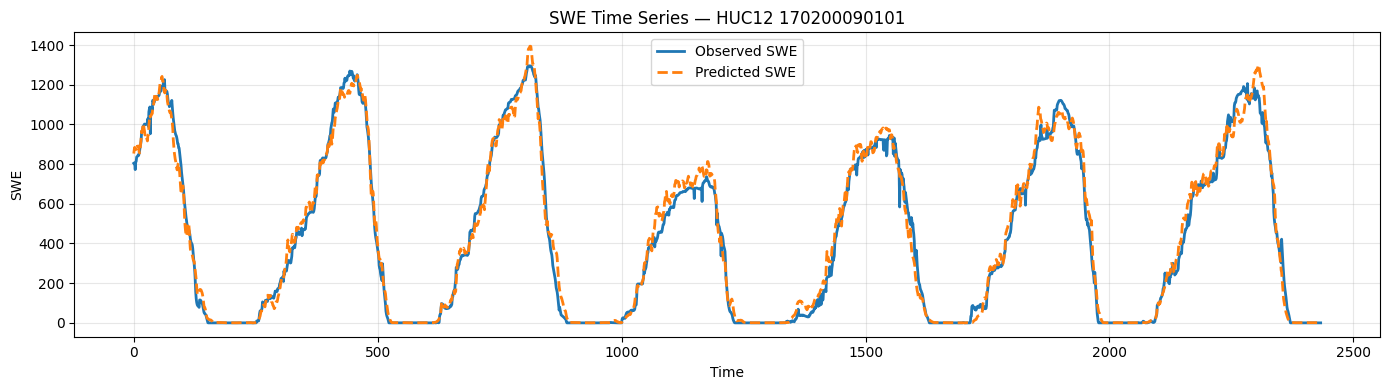

In [39]:
huc_idx = 0
y_true = targets[huc_idx]
y_pred = preds[huc_idx]

plt.figure(figsize=(14, 4))
plt.plot(y_true, label="Observed SWE", linewidth=2)
plt.plot(y_pred, label="Predicted SWE", linewidth=2, linestyle="--")

plt.title(f"SWE Time Series — HUC12 {huc12_ids[huc_idx]}")
plt.xlabel("Time")
plt.ylabel("SWE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

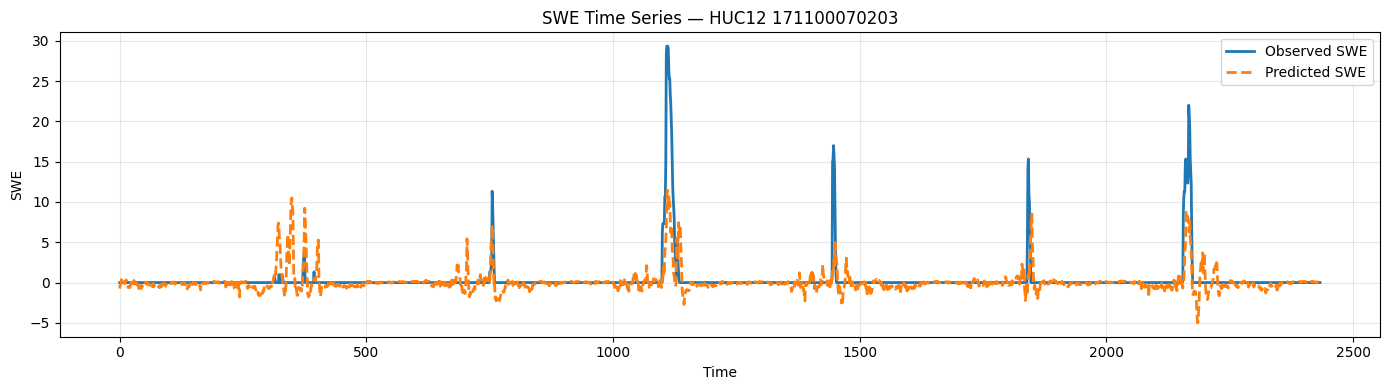

In [47]:
#huc with negative KGE
# Maritime = 170200090101
# Boreal Forest = 170200090205
# Ephemeral = 170200090206
# Montane Forest = 170200090208
# Prairie = 170103040607
huc12_to_plot="171100070203"
huc_idx = list(huc12_ids).index(huc12_to_plot)
y_true = targets[huc_idx]
y_pred = preds[huc_idx]

plt.figure(figsize=(14, 4))
plt.plot(y_true, label="Observed SWE", linewidth=2)
plt.plot(y_pred, label="Predicted SWE", linewidth=2, linestyle="--")

plt.title(f"SWE Time Series — HUC12 {huc12_ids[huc_idx]}")
plt.xlabel("Time")
plt.ylabel("SWE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

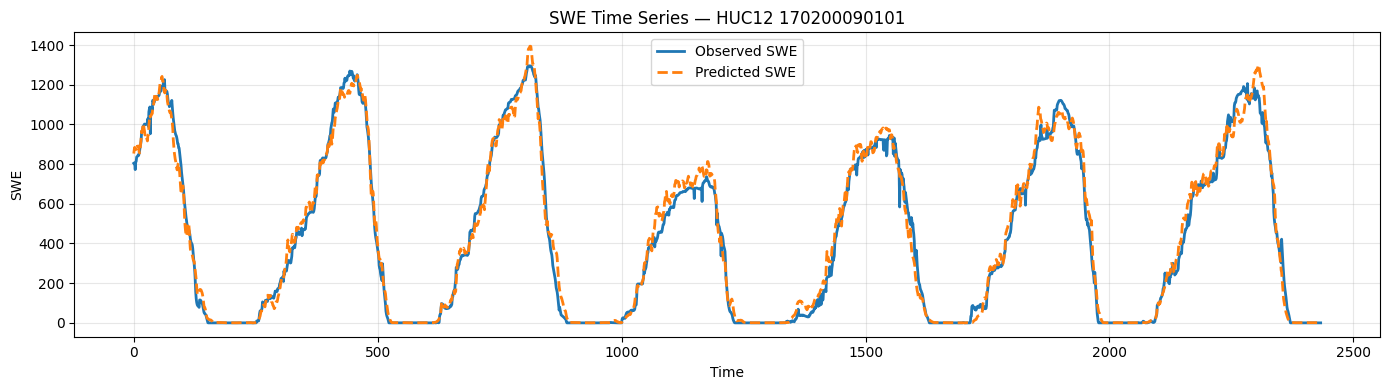

In [48]:
# Maritime = 170200090101
huc12_to_plot="170200090101"
huc_idx = list(huc12_ids).index(huc12_to_plot)
y_true = targets[huc_idx]
y_pred = preds[huc_idx]

plt.figure(figsize=(14, 4))
plt.plot(y_true, label="Observed SWE", linewidth=2)
plt.plot(y_pred, label="Predicted SWE", linewidth=2, linestyle="--")

plt.title(f"SWE Time Series — HUC12 {huc12_ids[huc_idx]}")
plt.xlabel("Time")
plt.ylabel("SWE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

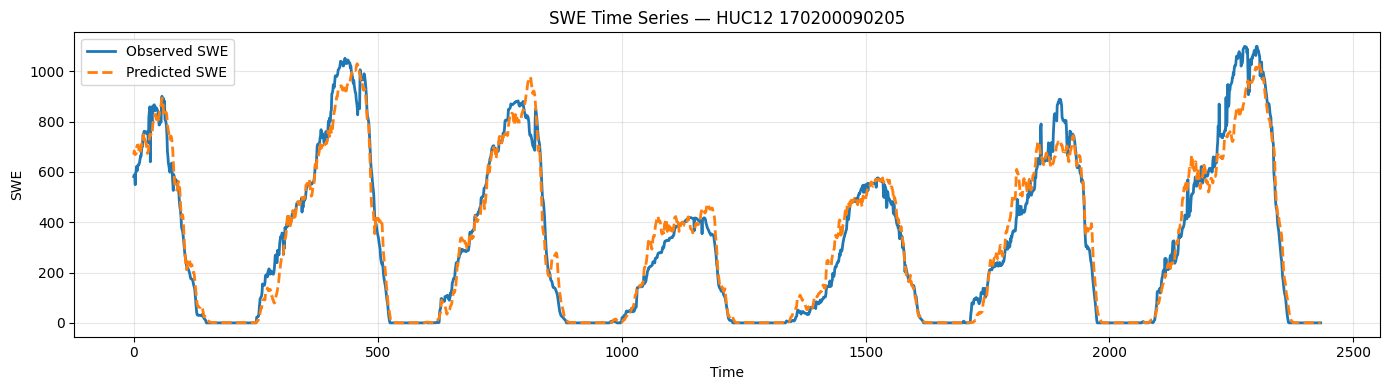

In [49]:
# Boreal Forest = 170200090205
huc12_to_plot="170200090205"
huc_idx = list(huc12_ids).index(huc12_to_plot)
y_true = targets[huc_idx]
y_pred = preds[huc_idx]

plt.figure(figsize=(14, 4))
plt.plot(y_true, label="Observed SWE", linewidth=2)
plt.plot(y_pred, label="Predicted SWE", linewidth=2, linestyle="--")

plt.title(f"SWE Time Series — HUC12 {huc12_ids[huc_idx]}")
plt.xlabel("Time")
plt.ylabel("SWE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

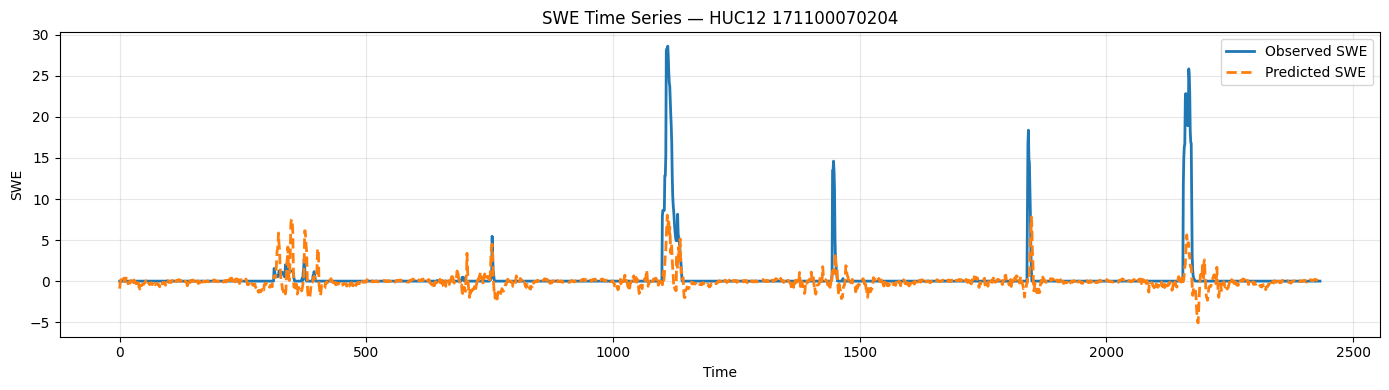

In [55]:
# Ephemeral = 171100070204
huc12_to_plot="171100070204"
huc_idx = list(huc12_ids).index(huc12_to_plot)
y_true = targets[huc_idx]
y_pred = preds[huc_idx]

plt.figure(figsize=(14, 4))
plt.plot(y_true, label="Observed SWE", linewidth=2)
plt.plot(y_pred, label="Predicted SWE", linewidth=2, linestyle="--")

plt.title(f"SWE Time Series — HUC12 {huc12_ids[huc_idx]}")
plt.xlabel("Time")
plt.ylabel("SWE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

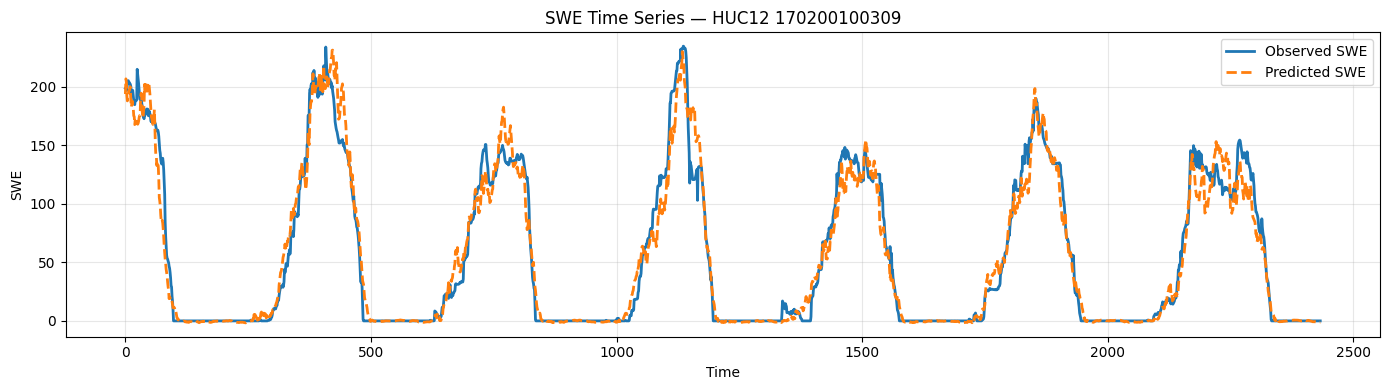

In [60]:
# Montane Forest = 170200100309
huc12_to_plot="170200100309"
huc_idx = list(huc12_ids).index(huc12_to_plot)
y_true = targets[huc_idx]
y_pred = preds[huc_idx]

plt.figure(figsize=(14, 4))
plt.plot(y_true, label="Observed SWE", linewidth=2)
plt.plot(y_pred, label="Predicted SWE", linewidth=2, linestyle="--")

plt.title(f"SWE Time Series — HUC12 {huc12_ids[huc_idx]}")
plt.xlabel("Time")
plt.ylabel("SWE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

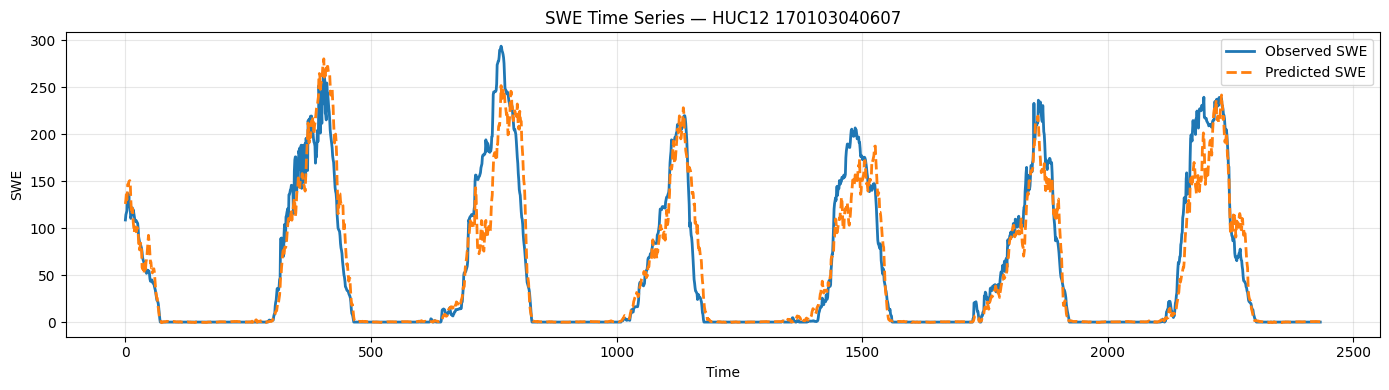

In [52]:
# Prairie = 170103040607
huc12_to_plot="170103040607"
huc_idx = list(huc12_ids).index(huc12_to_plot)
y_true = targets[huc_idx]
y_pred = preds[huc_idx]

plt.figure(figsize=(14, 4))
plt.plot(y_true, label="Observed SWE", linewidth=2)
plt.plot(y_pred, label="Predicted SWE", linewidth=2, linestyle="--")

plt.title(f"SWE Time Series — HUC12 {huc12_ids[huc_idx]}")
plt.xlabel("Time")
plt.ylabel("SWE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
huc_12s_wise[huc_12s_wise['snow_type'] =="Montane Forest"]

,huc12,huc8,snow_type,mean_elevation,mse,kge,mean_true_swe,mean_pred_swe
21,170200090208,17020009,Montane Forest,1642.865845,1954.007446,0.962733,201.408585,202.542511
22,170200090209,17020009,Montane Forest,1203.596558,2243.083740,0.951213,206.954391,216.239883
24,170200090301,17020009,Montane Forest,1331.436157,845.467651,0.958002,118.756783,118.476349
25,170200090302,17020009,Montane Forest,1191.954590,331.982117,0.965823,84.522461,85.518974
27,170200090304,17020009,Montane Forest,937.027222,371.636078,0.847846,49.271057,45.685631
...,...,...,...,...,...,...,...,...
497,170200100208,17020010,Montane Forest,1164.660889,1753.991821,0.913060,101.125885,108.670631
503,170200100305,17020010,Montane Forest,1006.625244,425.894318,0.899204,37.318817,38.622643
507,170200100309,17020010,Montane Forest,990.113159,184.624390,0.962276,54.465797,53.539497
508,170200100310,17020010,Montane Forest,1155.776978,187.680710,0.937561,66.746094,64.028526
